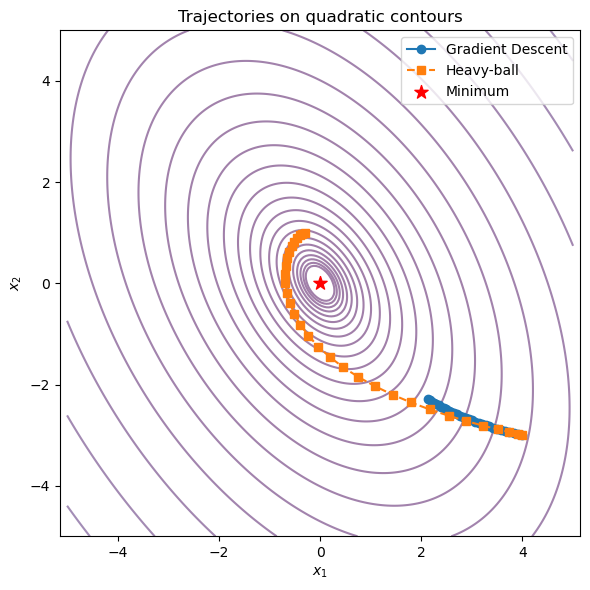

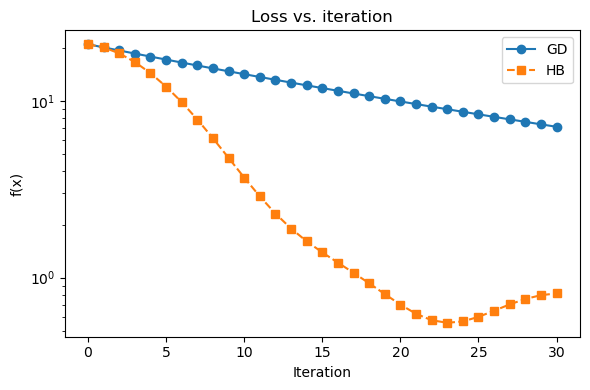

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Problem setup -------------------------------------------------------
# Positive–definite 2×2 matrix → f(x) = ½ xᵀAx
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])

def f(x):
    return 0.5 * x.T @ A @ x

def grad(x):
    return A @ x

# Hyper-parameters
α = 0.01            # step size
β = 0.9            # heavy-ball momentum coefficient
n_iter = 30        # iterations
x0 = np.array([4.0, -3.0])   # starting point

# ---- Gradient Descent ----------------------------------------------------
gd_path = [x0.copy()]
x = x0.copy()
for _ in range(n_iter):
    x = x - α * grad(x)
    gd_path.append(x.copy())

# ---- Heavy-ball momentum -------------------------------------------------
hb_path = [x0.copy()]
x_prev, x = x0.copy(), x0.copy()
for k in range(n_iter):
    update = -α * grad(x)
    if k > 0:
        update += β * (x - x_prev)
    x_prev, x = x, x + update
    hb_path.append(x.copy())

gd_path, hb_path = np.array(gd_path), np.array(hb_path)

# ---- Contour plot + trajectories ----------------------------------------
# Grid for contours
x1 = np.linspace(-5, 5, 200)
x2 = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 0.5 * (A[0,0]*X1**2 + 2*A[0,1]*X1*X2 + A[1,1]*X2**2)

plt.figure(figsize=(6, 6))
levels = np.logspace(-1, 3, 30)
plt.contour(X1, X2, Z, levels=levels, alpha=0.5)
plt.plot(gd_path[:,0], gd_path[:,1], 'o-', label='Gradient Descent')
plt.plot(hb_path[:,0], hb_path[:,1], 's--', label='Heavy-ball')
plt.scatter(0, 0, c='red', marker='*', s=100, label='Minimum')
plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.title('Trajectories on quadratic contours')
plt.legend(); plt.axis('equal'); plt.tight_layout()
plt.show()

# ---- Loss curves ---------------------------------------------------------
gd_loss = [f(p) for p in gd_path]
hb_loss = [f(p) for p in hb_path]

plt.figure(figsize=(6, 4))
plt.plot(gd_loss, 'o-', label='GD')
plt.plot(hb_loss, 's--', label='HB')
plt.yscale('log')
plt.xlabel('Iteration'); plt.ylabel('f(x)')
plt.title('Loss vs. iteration')
plt.legend(); plt.tight_layout()
plt.show()